**<center>M1 Seminar - 2026.4.9</center>**
**<center>_Topic_: OT(Oblivious Transfer) and OTE(Oblivious Transfer Extension)</center>**
<center>Group: Oskar Piibar, Celia Gimenez, Jianyu Liu</center>


#### List of notebook requirements:
1. Python 3
3. Numpy
4. Matplotlib
5. Hashlib
6. Secrets

#### Notebook usage:
- The notebook is interactive after executing it
- Please ignore all code section when reading this notebook. It is sufficient to look at the figures and read the markdowns.


In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import secrets
import time
from IPython.display import Image

In [11]:
# Helper functions

def measure_time(func, *args, **kwargs):
    """Run func(*args) and return (result, elapsed_ms)."""
    t0 = time.perf_counter()
    result = func(*args, **kwargs)
    return result, (time.perf_counter() - t0) * 1000


def H(*args) -> bytes:
    """
    Hash function (random oracle).
    Accepts ints, bytes, or numpy uint8 arrays.
    Returns 32 bytes.
    """
    h = hashlib.sha256()
    for a in args:
        if isinstance(a, int):
            h.update(a.to_bytes(8, 'big'))
        elif isinstance(a, (bytes, bytearray)):
            h.update(a)
        elif isinstance(a, np.ndarray):
            h.update(a.tobytes())   # deterministic: each uint8 element → 1 byte
    return h.digest()


def xor_bytes(a: bytes, b: bytes) -> bytes:
    """XOR two equal-length byte strings."""
    return bytes(x ^ y for x, y in zip(a, b))


def prg(seed: bytes, n_bits: int) -> np.ndarray:
    """
    Pseudorandom Generator — SHA-256 in counter mode.
    Expands `seed` (bytes) into `n_bits` pseudorandom bits (np.uint8 array).
    """
    buf = bytearray()
    ctr = 0
    while len(buf) * 8 < n_bits:
        buf += hashlib.sha256(seed + ctr.to_bytes(4, 'big')).digest()
        ctr += 1
    return np.unpackbits(np.frombuffer(bytes(buf), dtype=np.uint8))[:n_bits].astype(np.uint8)


# Secure Multiparty Computation — OT vs OT Extension
Comparing **Simple Oblivious Transfer** (DH-based) against
**IKNP OT Extension** (Ishai, Kilian, Nissim, Petrank 2003).

 

## Introduction

### Oblivious Transfer

Oblivious Transfer (OT) is a fundamental cryptographic protocol where a Sender has two messages $(M_0, M_1)$ and a Receiver chooses to receive one of them $(M_r)$. \
The protocol ensures two things:
1. Receiver Privacy: The Sender doesn't know which message the Receiver chose.
2. Sender Privacy: The Receiver only learns the chosen message and nothing about the other.

## Example problem

Bank A (the Sender) maintains a large database of $2^{13}$ (8,192) high-risk individuals on a credit blacklist. \
Bank B (the Receiver) has a potential loan applicant and wants to verify if this person is on Bank A's list without compromising privacy.\
Bank B cannot reveal the identity of its applicant to Bank A to prevent customer poaching or privacy leaks.\
Bank A cannot share its entire blacklist with Bank B to protect proprietary business data and comply with regulations.

![ot.png](ot.png)

## OT Solution


── DH group ──────────────────────────────────────────────────────────────
 
Using the Mersenne prime 2^61 − 1 for fast demo arithmetic.
A production implementation would use a 2048-bit safe prime (e.g. RFC 3526).

In [12]:
DH_P = (1 << 61) - 1   # Mersenne prime, 61 bits
DH_G = 2               # generator

### **Naor-Pinkas 1-out-of-2 OT (DH-based)**

---

#### 1. Participants & Objectives 
| Role | Possession | Goal |
| :--- | :--- | :--- |
| Sender  | Messages $m_0, m_1$ | Send $m_c$ without knowing $c$ |
| Receiver  | Choice $c \in \{0, 1\}$ | Get $m_c$ without learning $m_{1-c}$ |

---

#### 2. Protocol Steps 

**Step 1: Initialization  (Sender)**
- Sender generates a random secret $a \leftarrow \mathbb{Z}_p$ and broadcasts the public key $A = g^a$.


**Step 2: Blinding  (Receiver)**
- Receiver picks a random $b \leftarrow \mathbb{Z}_p$.
- Calculates $B$ based on choice $c$:
  - If $c=0$: $B = g^b$
  - If $c=1$: $B = A \cdot g^b$
- Receiver computes decryption key: $k_{recv} = A^b = g^{ab}$.

**Step 3: Encryption  (Sender)**
- Sender receives $B$ and derives two potential keys:
  - $k_0 = B^a$
  - $k_1 = (B/A)^a$
- Sender encrypts both: $e_0 = m_0 \oplus H(k_0)$, $e_1 = m_1 \oplus H(k_1)$.

**Step 4: Recovery  (Receiver)**
- Receiver recovers the message: $m_c = e_c \oplus H(k_{recv})$.

Security: computationally secure under the DDH assumption.\
Cost:     O(1) modular exponentiations per OT  ← the expensive part.

In [13]:


def simple_ot(m0: bytes, m1: bytes, choice: int) -> bytes:

    P, G = DH_P, DH_G

    # ── Sender setup ──────────────────────────────────────────────────────
    a = secrets.randbelow(P - 2) + 2
    A = pow(G, a, P)                        # A = g^a  [mod P]

    # ── Receiver encodes choice in public key B ───────────────────────────
    b = secrets.randbelow(P - 2) + 2
    if choice == 0:
        B = pow(G, b, P)                    # B = g^b
    else:
        B = (A * pow(G, b, P)) % P          # B = A · g^b
    k_recv = pow(A, b, P)                   # = A^b = g^(ab)

    # ── Sender builds two encryption keys ─────────────────────────────────
    k0 = pow(B, a, P)                       # k0 = B^a
    A_inv = pow(A, P - 2, P)               # A^{−1} mod P  (Fermat's little theorem)
    k1 = pow((B * A_inv) % P, a, P)        # k1 = (B/A)^a

    # ── Sender encrypts both messages ─────────────────────────────────────
    e0 = xor_bytes(m0, H(k0)[:len(m0)])
    e1 = xor_bytes(m1, H(k1)[:len(m1)])

    # ── Receiver decrypts the chosen message ──────────────────────────────
    pad = H(k_recv)[:len(m0)]
    return xor_bytes(e0 if choice == 0 else e1, pad)


# ── correctness check ─────────────────────────────────────────────────────
assert simple_ot(b"hello_m0__", b"hello_m1__", 0) == b"hello_m0__"
assert simple_ot(b"hello_m0__", b"hello_m1__", 1) == b"hello_m1__"
print("Simple OT  ✓  correctness check passed")


def bench_simple_ot(n: int) -> float:
    """Run n independent Simple OTs. Returns total wall-clock time in ms."""
    m0, m1 = secrets.token_bytes(16), secrets.token_bytes(16)
    t0 = time.perf_counter()
    for i in range(n):
        simple_ot(m0, m1, i % 2)
    return (time.perf_counter() - t0) * 1000


Simple OT  ✓  correctness check passed


![1-to-2-ot.png](1-to-2-ot.png)

## Bottleneck

Each 1-out-of-2 OT requires multiple modular exponentiations ($g^a, g^b, B^a$, etc.). These are "heavy" asymmetric cryptographic operations. If Bank A’s database has $N=8192$ ($2^{13}$) records, performing 8192 individual OT protocols would consume massive CPU cycles and cause significant latency.\
The cost of base OT scales linearly with the number of queries. In a real-world financial system with millions of checks, $O(N)$ modular exponentiations are simply not scalable. The server would be overwhelmed by the sheer volume of complex math before a single verification is completed.

![ot-limits.png](ot-limits.png)

## OT Extension (IKNP Protocol)

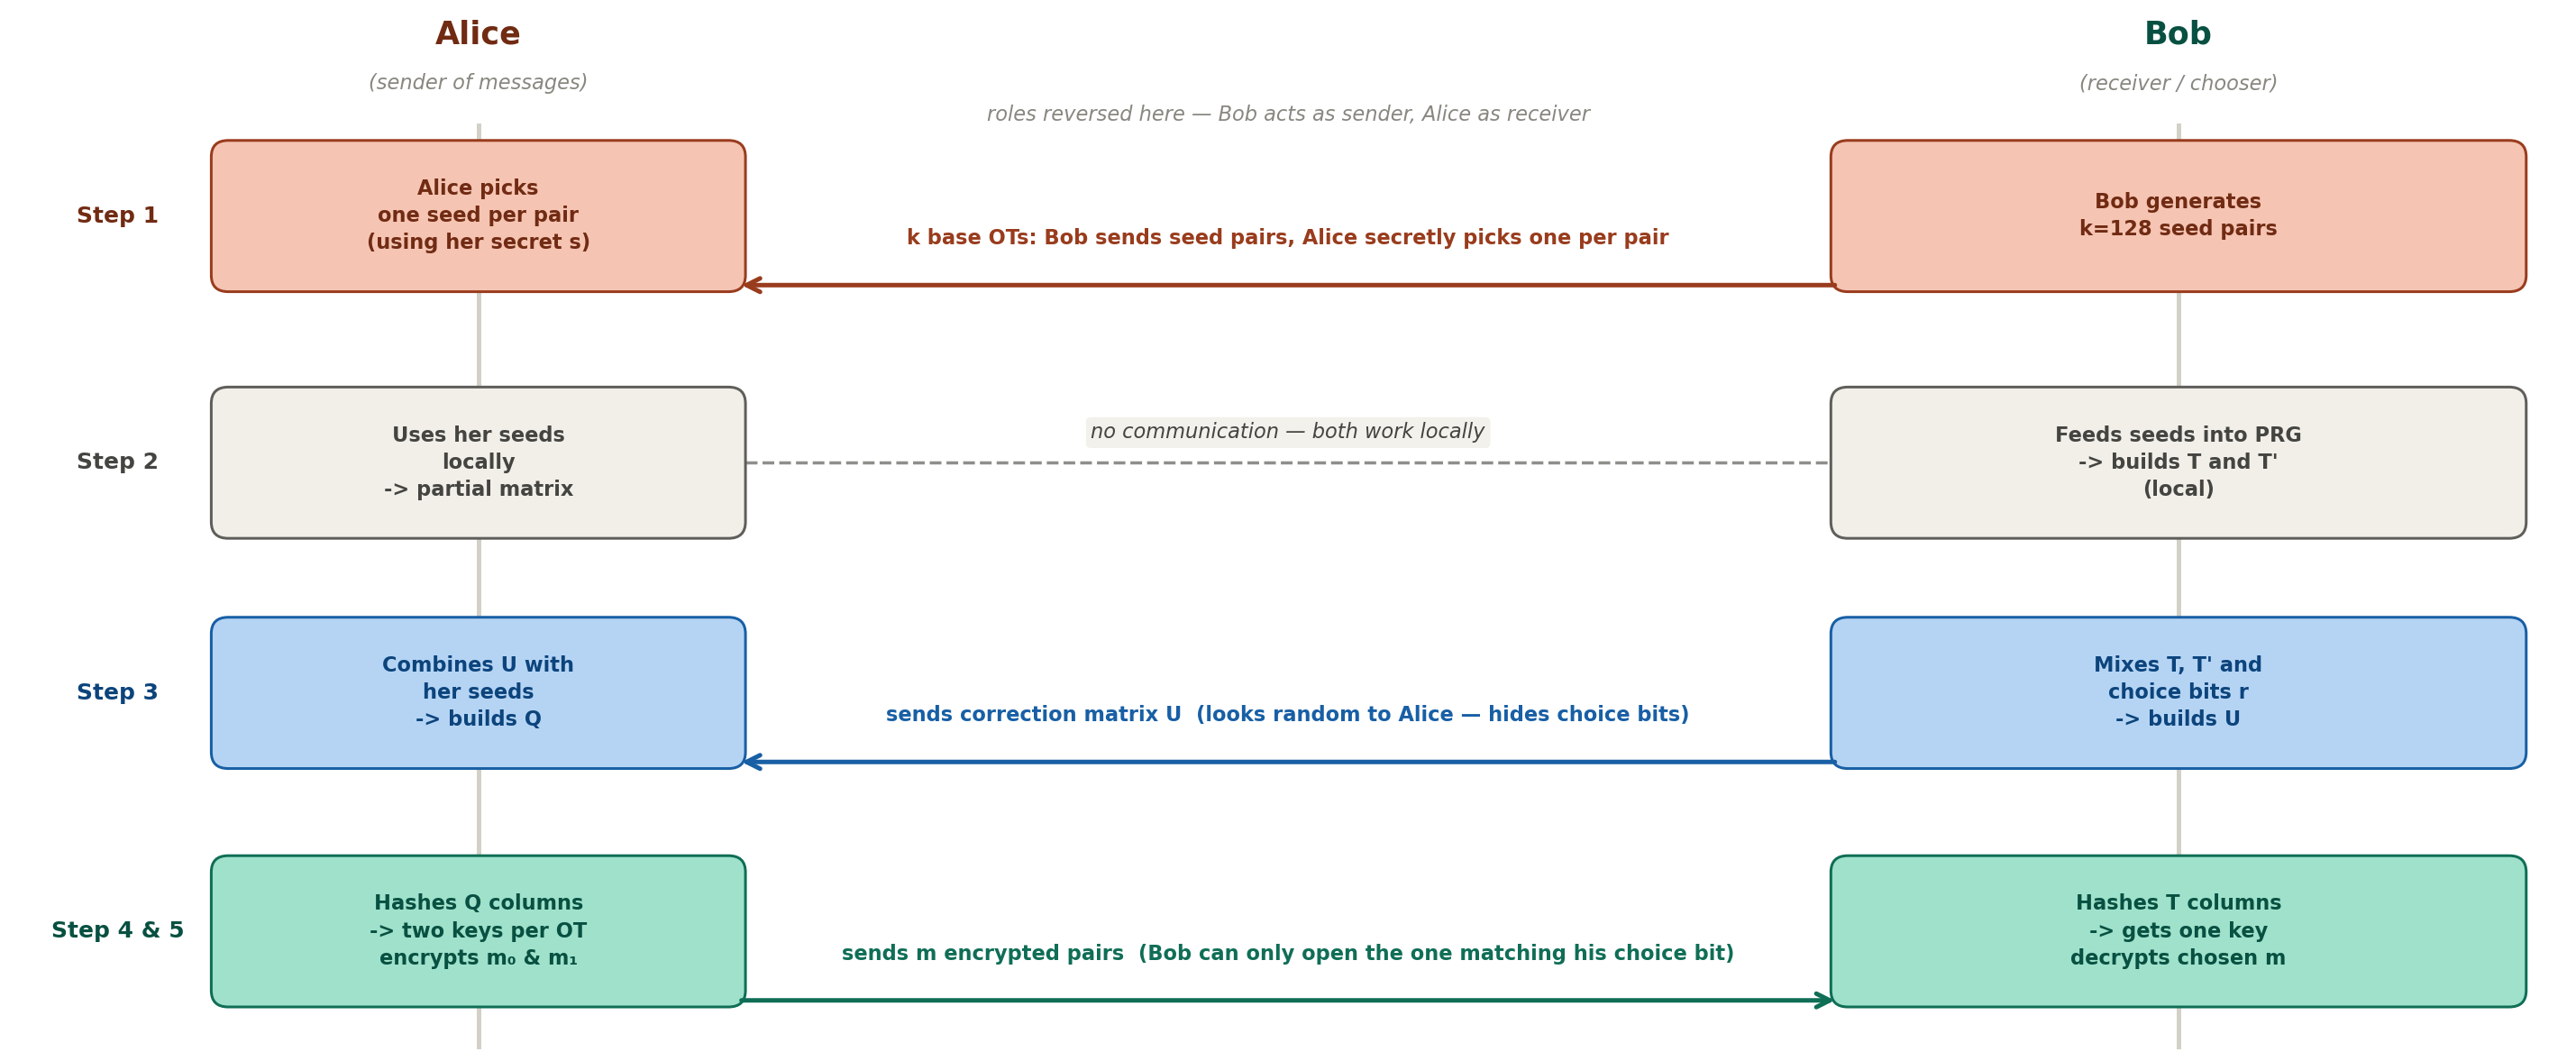

In [6]:
Image('ote_diagram.png')

In [33]:
def hash_vector(vec):
    """Hash a binary vector into a short digest"""
    s = ''.join(map(str, vec))
    return hashlib.sha256(s.encode()).hexdigest()[:8]

def ote_demo_alice_bob(k=3, N=4):
    print("\n==============================")
    print("   OTE DEMO (Alice & Bob)")
    print("==============================\n")

    print(f"Security parameter k = {k}")
    print("→ Number of base OTs (controls security level)\n")

    print(f"Number of OTs to generate N = {N}")
    print("→ Number of oblivious transfers (e.g., number of bits to transfer)\n")


    # ---------------------------
    # Step 1: Base OT (role reversed)
    # ---------------------------
    print("Step 1: Base OTs (roles reversed)")
    print("Bob (receiver) generates seed pairs")
    print("Alice (sender) selects one per pair using c\n")
    
    # Bob's choice bits (for final OT)
    c = np.random.randint(0, 2, size=N)
    
    # Alice's base OT choices (r vector)
    r = np.random.randint(0, 2, size=k)
    
    print("Bob's choice bits r (what he wants to receive):")
    print("r =", c, "\n")
    
    print("Alice's base OT selection bits c:")
    print("c =", r, "\n")
    
    # ---------------------------
    # Step 2: Bob builds matrix T
    # ---------------------------
    print("Step 2: Bob builds random matrix T (k x N)\n")
    
    T = np.random.randint(0, 2, size=(k, N))
    print("T matrix:")
    print(T, "\n")
    
    # ---------------------------
    # Step 3: Bob computes U = T XOR c
    # ---------------------------
    print("Step 3: Bob computes correction matrix U = T XOR r\n")
    
    U = T ^ c
    
    print("U matrix (each row of T XORed with r):")
    print(U, "\n")
    
    print("Bob sends U to Alice\n")
    
    # ---------------------------
    # Step 4: Alice reconstructs Q
    # ---------------------------
    print("Step 4: Alice reconstructs Q using c\n")
    
    Q = np.zeros_like(T)
    
    for i in range(k):
        if r[i] == 0:
            Q[i] = T[i]
            print(f"Row {i}: c[{i}] = 0 → take T[{i}]")
        else:
            Q[i] = U[i]
            print(f"Row {i}: c[{i}] = 1 → take U[{i}]")
    
    print("\nQ matrix (Alice's view):")
    print(Q, "\n")
    
    # ---------------------------
    # Step 5: Hashing (key derivation)
    # ---------------------------
    print("Step 5: Key derivation + encryption using hashing\n")
    print("Alice derives two keys per OT and encrypts two messages (m0, m1)")
    print("Bob derives one key and can only decrypt one message\n")
        
    for j in range(N):
        T_col = T[:, j]
        Q_col = Q[:, j]
        
        k_bob = hash_vector(T_col)
        k0 = hash_vector(Q_col)
        k1 = hash_vector(Q_col ^ r)

        # Example messages (what Alice wants to send)
        m0 = f"Message_0_for_OT_{j}"
        m1 = f"Message_1_for_OT_{j}"

        # "Encrypt" using XOR with hashed key (toy demo)
        def xor_encrypt(msg, key):
            return ''.join(chr(ord(a) ^ ord(b)) for a, b in zip(msg, key))

        # Extend key to match message length
        k0_ext = (k0 * ((len(m0) // len(k0)) + 1))[:len(m0)]
        k1_ext = (k1 * ((len(m1) // len(k1)) + 1))[:len(m1)]

        e0 = xor_encrypt(m0, k0_ext)
        e1 = xor_encrypt(m1, k1_ext)

        # Bob decrypts only one
        k_bob_ext = (k_bob * ((len(m0) // len(k_bob)) + 1))[:len(m0)]
        decrypted = xor_encrypt(e1 if c[j] else e0, k_bob_ext)
        
        chosen = k1 if c[j] else k0
        
        print(f"--- OT #{j+1} ---")
        print(f"Bob's choice bit r[{j}] = {c[j]}")
        print(f"T column: {T_col}")
        print(f"Q column: {Q_col}\n")

        print(f"Alice encrypts:")
        print(f"  m0: {m0}")
        print(f"  m1: {m1}")

        print(f"Encrypted messages:")
        print(f"  e0: {e0}")
        print(f"  e1: {e1}")

        print(f"Bob decrypts using his key:")
        print(f"  Decrypted message: {decrypted}\n")

        print(f"Bob's key: {k_bob}")
        print(f"Alice k0:  {k0}")
        print(f"Alice k1:  {k1}")
        print(f"Match:     {k_bob == chosen}\n")

        

# Run demo
ote_demo_alice_bob()


   OTE DEMO (Alice & Bob)

Security parameter k = 3
→ Number of base OTs (controls security level)

Number of OTs to generate N = 4
→ Number of oblivious transfers (e.g., number of bits to transfer)

Step 1: Base OTs (roles reversed)
Bob (receiver) generates seed pairs
Alice (sender) selects one per pair using c

Bob's choice bits r (what he wants to receive):
r = [1 1 0 0] 

Alice's base OT selection bits c:
c = [1 0 0] 

Step 2: Bob builds random matrix T (k x N)

T matrix:
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]] 

Step 3: Bob computes correction matrix U = T XOR r

U matrix (each row of T XORed with r):
[[1 1 1 1]
 [1 1 1 1]
 [1 1 0 0]] 

Bob sends U to Alice

Step 4: Alice reconstructs Q using c

Row 0: c[0] = 1 → take U[0]
Row 1: c[1] = 0 → take T[1]
Row 2: c[2] = 0 → take T[2]

Q matrix (Alice's view):
[[1 1 1 1]
 [0 0 1 1]
 [0 0 0 0]] 

Step 5: Key derivation + encryption using hashing

Alice derives two keys per OT and encrypts two messages (m0, m1)
Bob derives one key and can only 

In [24]:
def iknp_ote(sender_m0: list,
             sender_m1: list,
             receiver_choices: np.ndarray,
             k: int = 128) -> list:

    m = len(receiver_choices)
    r = receiver_choices.astype(np.uint8)                # (m,)

    # ── Step 1: Sender samples s ∈ {0,1}^k ───────────────────────────────
    s_raw = secrets.token_bytes((k + 7) // 8)
    s = np.unpackbits(np.frombuffer(s_raw, dtype=np.uint8))[:k].astype(np.uint8)  # (k,)

    # ── Step 2: k base OTs ────────────────────────────────────────────────
    # R provides seed pairs; S picks with s[j].  Only k DH operations here.
    seeds0 = [secrets.token_bytes(16) for _ in range(k)]
    seeds1 = [secrets.token_bytes(16) for _ in range(k)]
    q_keys = [simple_ot(seeds0[j], seeds1[j], int(s[j])) for j in range(k)]

    # ── Step 3: R builds T (k×m) and correction U ─────────────────────────
    T = np.array([prg(seeds0[j], m) for j in range(k)], dtype=np.uint8)   # (k, m)
    U = np.array(
        [prg(seeds1[j], m) ^ T[j] ^ r for j in range(k)], dtype=np.uint8
    )                                                                       # (k, m)

    # ── Step 4: S builds Q (k×m) ─────────────────────────────────────────
    Q = np.array(
        [prg(q_keys[j], m) ^ (s[j] * U[j]) for j in range(k)], dtype=np.uint8
    )                                                                       # (k, m)

    # ── Step 5: Transfer m messages using hashing ─────────────────────────
    Qt = Q.T   # (m, k): Qt[i] = i-th row of Q  =  Q_i
    Tt = T.T   # (m, k): Tt[i] = i-th row of T  =  T_i

    results = []
    for i in range(m):
        key0 = H(i, Qt[i])
        key1 = H(i, (Qt[i] ^ s).astype(np.uint8))

        e0 = xor_bytes(sender_m0[i], key0[:len(sender_m0[i])])
        e1 = xor_bytes(sender_m1[i], key1[:len(sender_m1[i])])

        recv_key = H(i, Tt[i])
        chosen   = e0 if r[i] == 0 else e1
        results.append(xor_bytes(chosen, recv_key[:len(sender_m0[i])]))

    return results


# ── correctness check (k=16 for speed) ───────────────────────────────────
_m0 = [b"msg_0_" + bytes([i]) for i in range(20)]
_m1 = [b"msg_1_" + bytes([i]) for i in range(20)]
_ch = np.array([i % 2 for i in range(20)], dtype=np.uint8)
_res = iknp_ote(_m0, _m1, _ch, k=16)
for i in range(20):
    assert _res[i] == (_m0[i] if _ch[i] == 0 else _m1[i])
print("IKNP OTE   ✓  correctness check passed")


def bench_iknp_ote(n: int, k: int = 128) -> float:
    """Run IKNP OTE for n messages. Returns total wall-clock time in ms."""
    m0 = [secrets.token_bytes(16)] * n
    m1 = [secrets.token_bytes(16)] * n
    choices = np.array([i % 2 for i in range(n)], dtype=np.uint8)
    t0 = time.perf_counter()
    iknp_ote(m0, m1, choices, k=k)
    return (time.perf_counter() - t0) * 1000

IKNP OTE   ✓  correctness check passed



Benchmarking Simple OT  (averaged over 5 runs)…
  n =     1        0.26 ± 0.04 ms
  n =     2        0.24 ± 0.03 ms
  n =     4        0.46 ± 0.01 ms
  n =     8        0.96 ± 0.06 ms
  n =    16        1.93 ± 0.16 ms
  n =    32        3.69 ± 0.24 ms
  n =    64        7.03 ± 0.24 ms
  n =   128       19.56 ± 2.49 ms
  n =   256       37.00 ± 3.84 ms
  n =   512       64.84 ± 1.83 ms
  n =  1024      131.50 ± 9.14 ms
  n =  2048      285.73 ± 67.40 ms
  n =  4096      705.99 ± 85.54 ms
  n =  8192     1205.83 ± 168.60 ms

Benchmarking IKNP OTE  k=128  (averaged over 5 runs)…
  n =     1       21.02 ± 2.18 ms
  n =     2       22.13 ± 2.37 ms
  n =     4       26.79 ± 2.10 ms
  n =     8       26.19 ± 3.05 ms
  n =    16       22.22 ± 1.93 ms
  n =    32       25.59 ± 4.21 ms
  n =    64       26.12 ± 3.13 ms
  n =   128       28.69 ± 4.78 ms
  n =   256       48.43 ± 7.86 ms
  n =   512       70.46 ± 19.09 ms
  n =  1024       70.48 ± 5.76 ms
  n =  2048      131.83 ± 7.22 ms
  n =  

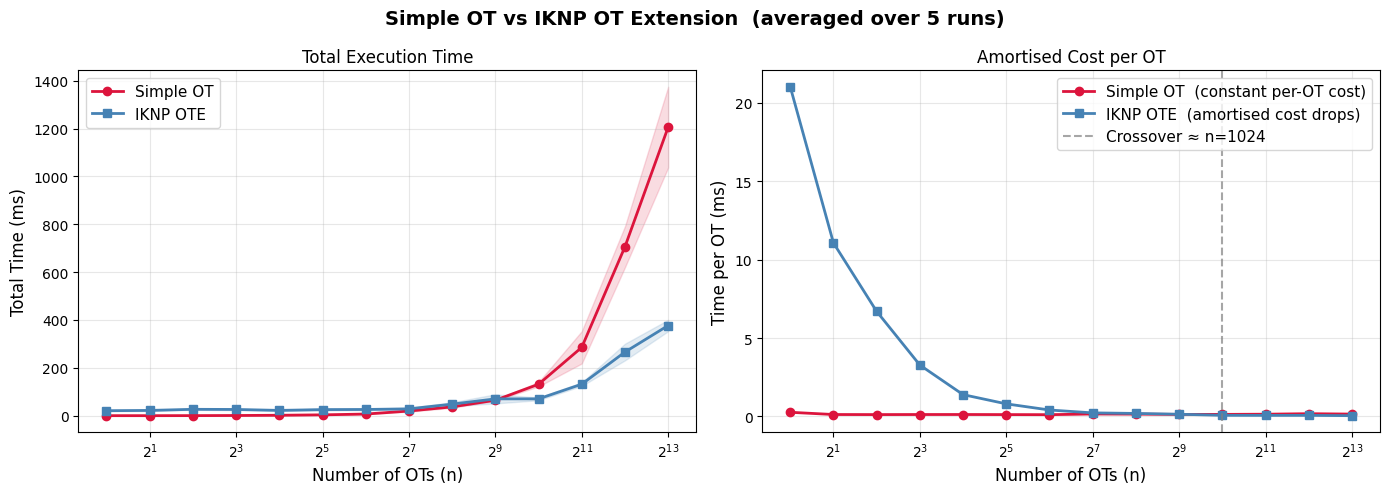


══════════════════════════════════════════════════
  Summary at n = 8192 OTs
══════════════════════════════════════════════════
  Simple OT :  0.1472 ms / OT
  IKNP OTE  :  0.0460 ms / OT
  Speedup   :  3.2×
  Crossover :  n ≈ 1024  (IKNP wins beyond this point)


In [17]:
# Plot the graphs

# Extended n range — goes well past the IKNP crossover point (~k=128)
N_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

# Number of repetitions to average over — smooths out OS/cache noise
REPS = 5


def bench_avg(bench_fn, n, reps=REPS, **kwargs) -> tuple[float, float]:
    """
    Run bench_fn(n) `reps` times and return (mean_ms, std_ms).
    Averaging eliminates the OS scheduling noise that caused the
    IKNP curve to look jagged at small n.
    """
    times = [bench_fn(n, **kwargs) for _ in range(reps)]
    return float(np.mean(times)), float(np.std(times))


print(f"\nBenchmarking Simple OT  (averaged over {REPS} runs)…")
simple_mean, simple_std = [], []
for n in N_VALUES:
    mean, std = bench_avg(bench_simple_ot, n)
    simple_mean.append(mean)
    simple_std.append(std)
    print(f"  n = {n:5d}   {mean:9.2f} ± {std:.2f} ms")

print(f"\nBenchmarking IKNP OTE  k=128  (averaged over {REPS} runs)…")
iknp_mean, iknp_std = [], []
for n in N_VALUES:
    mean, std = bench_avg(bench_iknp_ote, n, k=128)
    iknp_mean.append(mean)
    iknp_std.append(std)
    print(f"  n = {n:5d}   {mean:9.2f} ± {std:.2f} ms")

# ── amortised per-OT cost ─────────────────────────────────────────────────
simple_per_ot = [m / n for m, n in zip(simple_mean, N_VALUES)]
iknp_per_ot   = [m / n for m, n in zip(iknp_mean,  N_VALUES)]

# ── plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Simple OT vs IKNP OT Extension  (averaged over {REPS} runs)",
    fontsize=14, fontweight='bold'
)

# Left — total time with shaded ±1 std band
ax1.plot(N_VALUES, simple_mean, 'o-', color='crimson',   lw=2, label='Simple OT')
ax1.fill_between(N_VALUES,
                 [m - s for m, s in zip(simple_mean, simple_std)],
                 [m + s for m, s in zip(simple_mean, simple_std)],
                 color='crimson', alpha=0.15)

ax1.plot(N_VALUES, iknp_mean, 's-', color='steelblue', lw=2, label='IKNP OTE')
ax1.fill_between(N_VALUES,
                 [m - s for m, s in zip(iknp_mean, iknp_std)],
                 [m + s for m, s in zip(iknp_mean, iknp_std)],
                 color='steelblue', alpha=0.15)

ax1.set_xscale('log', base=2)
ax1.set_xlabel('Number of OTs (n)', fontsize=12)
ax1.set_ylabel('Total Time (ms)',   fontsize=12)
ax1.set_title('Total Execution Time')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right — amortised cost per OT
ax2.plot(N_VALUES, simple_per_ot, 'o-', color='crimson',
         lw=2, label='Simple OT  (constant per-OT cost)')
ax2.plot(N_VALUES, iknp_per_ot,   's-', color='steelblue',
         lw=2, label='IKNP OTE  (amortised cost drops)')

# Mark the crossover point
crossover_n = None
for i in range(len(N_VALUES) - 1):
    if iknp_per_ot[i] > simple_per_ot[i] and iknp_per_ot[i+1] <= simple_per_ot[i+1]:
        crossover_n = N_VALUES[i+1]
        ax2.axvline(crossover_n, color='gray', lw=1.5, ls='--', alpha=0.7,
                    label=f'Crossover ≈ n={crossover_n}')
        break

ax2.set_xscale('log', base=2)
ax2.set_xlabel('Number of OTs (n)', fontsize=12)
ax2.set_ylabel('Time per OT (ms)',   fontsize=12)
ax2.set_title('Amortised Cost per OT')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ot_vs_ote.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*50}")
print(f"  Summary at n = {N_VALUES[-1]} OTs")
print(f"{'═'*50}")
print(f"  Simple OT :  {simple_per_ot[-1]:.4f} ms / OT")
print(f"  IKNP OTE  :  {iknp_per_ot[-1]:.4f} ms / OT")
print(f"  Speedup   :  {simple_per_ot[-1] / iknp_per_ot[-1]:.1f}×")
if crossover_n:
    print(f"  Crossover :  n ≈ {crossover_n}  (IKNP wins beyond this point)")